## Сделаем классификацию отзывов при помощи BERT!

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/kyakovlev/yandex-geo-reviews-dataset-2023/geo-reviews-dataset-2023.csv")
df

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...
...,...,...,...,...,...
499995,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ..."
499996,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...
499997,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная..."
499998,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...


In [2]:
df.rating.value_counts()

rating
5.0    390515
4.0     41160
1.0     34351
3.0     21686
2.0     12088
0.0       200
Name: count, dtype: int64

Стратегия подготовки данных для бинарной классификации отзывов:

Для решения задачи автоматического обнаружения критических отзывов мы применяем следующую логику трансформации исходных данных:

Мы преобразуем числовые рейтинги в бинарные метки согласно бизнес-целям:

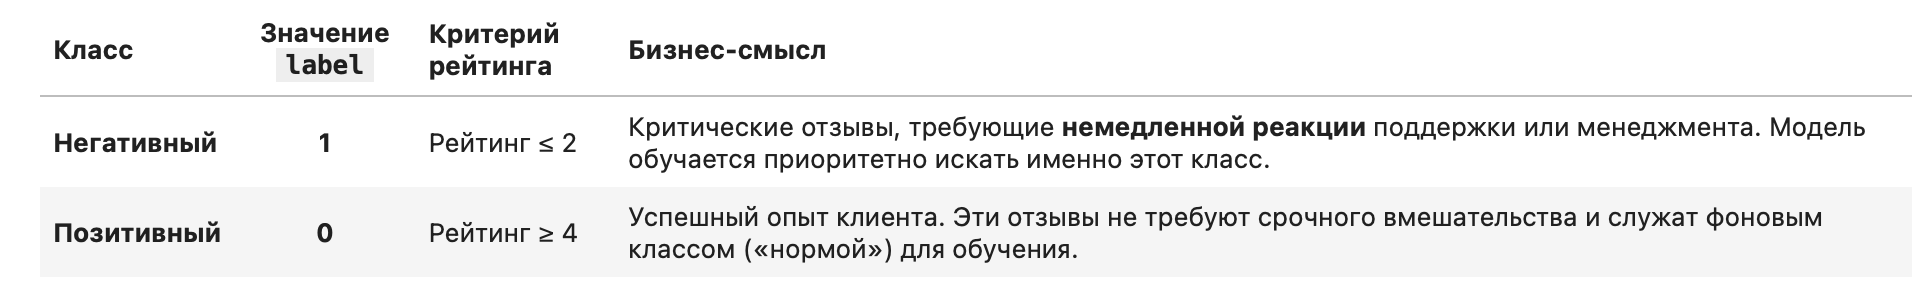

Отзывы с рейтингом 3 полностью удаляются из датасета перед обучением.
Обоснование: Нейтральные оценки часто неоднозначны по тональности. Их наличие может «размыть» границу принятия решений моделью, снизив её способность четко различать полярные случаи (явно плохо vs явно хорошо).

In [3]:
df_prepared = df[(df['rating'] <= 2) | (df['rating'] >= 4)].copy()

# Дедупликация по тексту отзыва
df_prepared = df_prepared.drop_duplicates(subset=['text'], keep='first').copy()

# Создание целевой переменной (label)
# 1 — негативный отзыв (рейтинг <= 2)
# 0 — позитивный отзыв (рейтинг >= 4)
df_prepared['label'] = (df_prepared['rating'] <= 2).astype(int)

# Сброс индекса
df_prepared = df_prepared.reset_index(drop=True)

In [4]:
df_prepared

,address,name_ru,rating,rubrics,text,label
0,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ...",0
1,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я...",1
2,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...,0
3,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...,0
4,"Иркутская область, Черемхово, Первомайская ули...",Tele2,5.0,Оператор сотовой связи;Интернет-провайдер,"Приятное общение, все доступно объяснили, мне ...",0
...,...,...,...,...,...,...
478194,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ...",0
478195,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...,0
478196,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная...",0
478197,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...,0


In [5]:
df_prepared.label.value_counts()

label
0    431560
1     46639
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

# ==========================================================================================================
# Разделение на train / validation / test с сохранением пропорций классов 70% трейн 10% валидация и 20% тест
# ==========================================================================================================

# Шаг 1: Отделяем тестовую выборку (20% от всего датасета)
# stratify по label сохраняет пропорцию классов (0 и 1)
df_train_val, df_test = train_test_split(
    df_prepared,
    test_size=0.2,           # 20% на тест
    random_state=42,         # фиксируем случайность для воспроизводимости
    stratify=df_prepared['label'],  # сохраняем пропорцию классов
)

# Шаг 2: Разделяем оставшиеся 80% на train (70%) и validation (10%)
# 10% / 80% = 0.125 (12.5% от оставшихся данных пойдут на валидацию)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.125,         # 12.5% от 80% = 10% от общего датасета
    random_state=42,
    stratify=df_train_val['label'],  # сохраняем пропорцию классов
)

# Сбрасываем индексы для удобства
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [7]:
print(f"\nОбщий размер: {len(df_prepared)} отзывов")
print(f"\nРазмеры выборок:")
print(f"  Train:      {len(df_train)} ({len(df_train)/len(df_prepared)*100:.1f}%)")
print(f"  Validation: {len(df_val)}   ({len(df_val)/len(df_prepared)*100:.1f}%)")
print(f"  Test:       {len(df_test)}  ({len(df_test)/len(df_prepared)*100:.1f}%)")

print(f"\nРаспределение классов на train:")
print(df_train['label'].value_counts(normalize=True).sort_index())


Общий размер: 478199 отзывов

Размеры выборок:
  Train:      334739 (70.0%)
  Validation: 47820   (10.0%)
  Test:       95640  (20.0%)

Распределение классов на train:
label
0    0.90247
1    0.09753
Name: proportion, dtype: float64


## Приступаем к обучению моделей

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
from tqdm.auto import tqdm
import os
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

Основные параметры модели:
Модель что будем использовать для тюнинга - https://huggingface.co/intfloat/multilingual-e5-small

In [9]:
# Задаем параметры
MODEL_NAME = 'intfloat/multilingual-e5-small' # модель которая знает все языки
BATCH_SIZE = 256
MAX_LENGTH = 64
NUM_EPOCHS = 10
RANDOM_SEED = 42

In [10]:
import numpy as np
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

## Рассмотрим работу токенизатора

In [11]:
# Инициализируем токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

XLMRobertaTokenizer(name_or_path='intfloat/multilingual-e5-small', vocab_size=250002, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	250001: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

Наша модель изначально была обучена на поиск похожих слов поэтому для классификации удобно дообучить

In [12]:
text = "Всем привет я Даши! Добро пожаловать на лекцию по NLP"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors='pt'
)
print(encoding)

{'input_ids': tensor([[     0,   7762,    130, 146038,    784,   1721,   4774,     38,  71133,
         149558,  27224,     29,  30031,  22959,    129,    541,  37352,      2,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


In [13]:
from termcolor import colored

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
attention_mask = encoding['attention_mask'][0]
input_ids = encoding['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()

## здесь демонстрация как именно работает токенизатор


№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17   
           ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Токены:      <s>   _Все     м   _привет  _я     _Да    ши      !   _Добро _пожал  овать   _на   _лек    цию    _по    _N     LP    </s>  
ID:           0    7762    130  146038   784   1721   4774    38    71133 149558  27224   29    30031  22959   129    541   37352    2   


посмотрим как отличается токенизатор в зависимости от модели

In [14]:
# Инициализируем другой токенизатор чтобы заметить разницу
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

text = "Всем привет я Дмитрий! Добро пожаловать на лекцию по NLP"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
attention_mask = encoding['attention_mask'][0]
input_ids = encoding['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13   
           ──────────────────────────────────────────────────────────────────────────────────────────────────
Токены:     [CLS]  Всем  привет    я   Дмитрий   !    Добро пожаловать  на   лекцию   по     NL     ##P   [SEP] 
ID:          101   15393  26856   877   13008   106   89537 105733  1469   88626  1516   81642   201    102  


тут появились cls токен и sep

In [15]:
# Создаем датасет
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts = df.text.tolist()
        self.labels = df.label.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float)
        }

In [16]:
# Создаем датасеты и даталоадеры
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # берем e5

train_dataset = TextDataset(
    df_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = TextDataset(
    df_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = TextDataset(
    df_test,
    tokenizer,
    MAX_LENGTH
)

In [17]:
train_dataset[200]

{'input_ids': tensor([     0,   3858,    546,  47981,    183,  19108,      5,   1087,  76291,
          27752,    244,   1009, 100414,    559,      5, 153191,   6103,     29,
            190,   1328,   1203,  24405,   5509,     35,  73013,  25172,   5509,
              5,   1087,  72794,  55057,     35, 150314,      9,   3549, 124107,
             49,     61,  41341,     59,  29015, 224193,  10130,     15,   2180,
            130,  13636,  34358,      4, 110378,  16051,      4,   1045,   1707,
              4,  43526,    415,    194, 153191,   6103,    255,    744,  66813,
              2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'label': tensor(0.)}

In [18]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
batch = next(iter(train_loader))
batch

{'input_ids': tensor([[     0,   1721,  26958,  ...,  36562, 146038,      2],
         [     0, 212309,   2192,  ...,  41661,   9977,      2],
         [     0,   7762, 213683,  ...,      1,      1,      1],
         ...,
         [     0,   5188, 121760,  ...,      1,      1,      1],
         [     0,   3858,    546,  ...,      1,      1,      1],
         [     0,  61421,     89,  ...,      1,      1,      1]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'label': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
    

In [20]:
batch["input_ids"].shape

torch.Size([256, 64])

In [21]:
batch["attention_mask"].shape

torch.Size([256, 64])

In [22]:
len(train_loader)

1308

## Выбираем модель для fine tuning
Рассмотрим каие есть варианты архитектур для классификации текста:

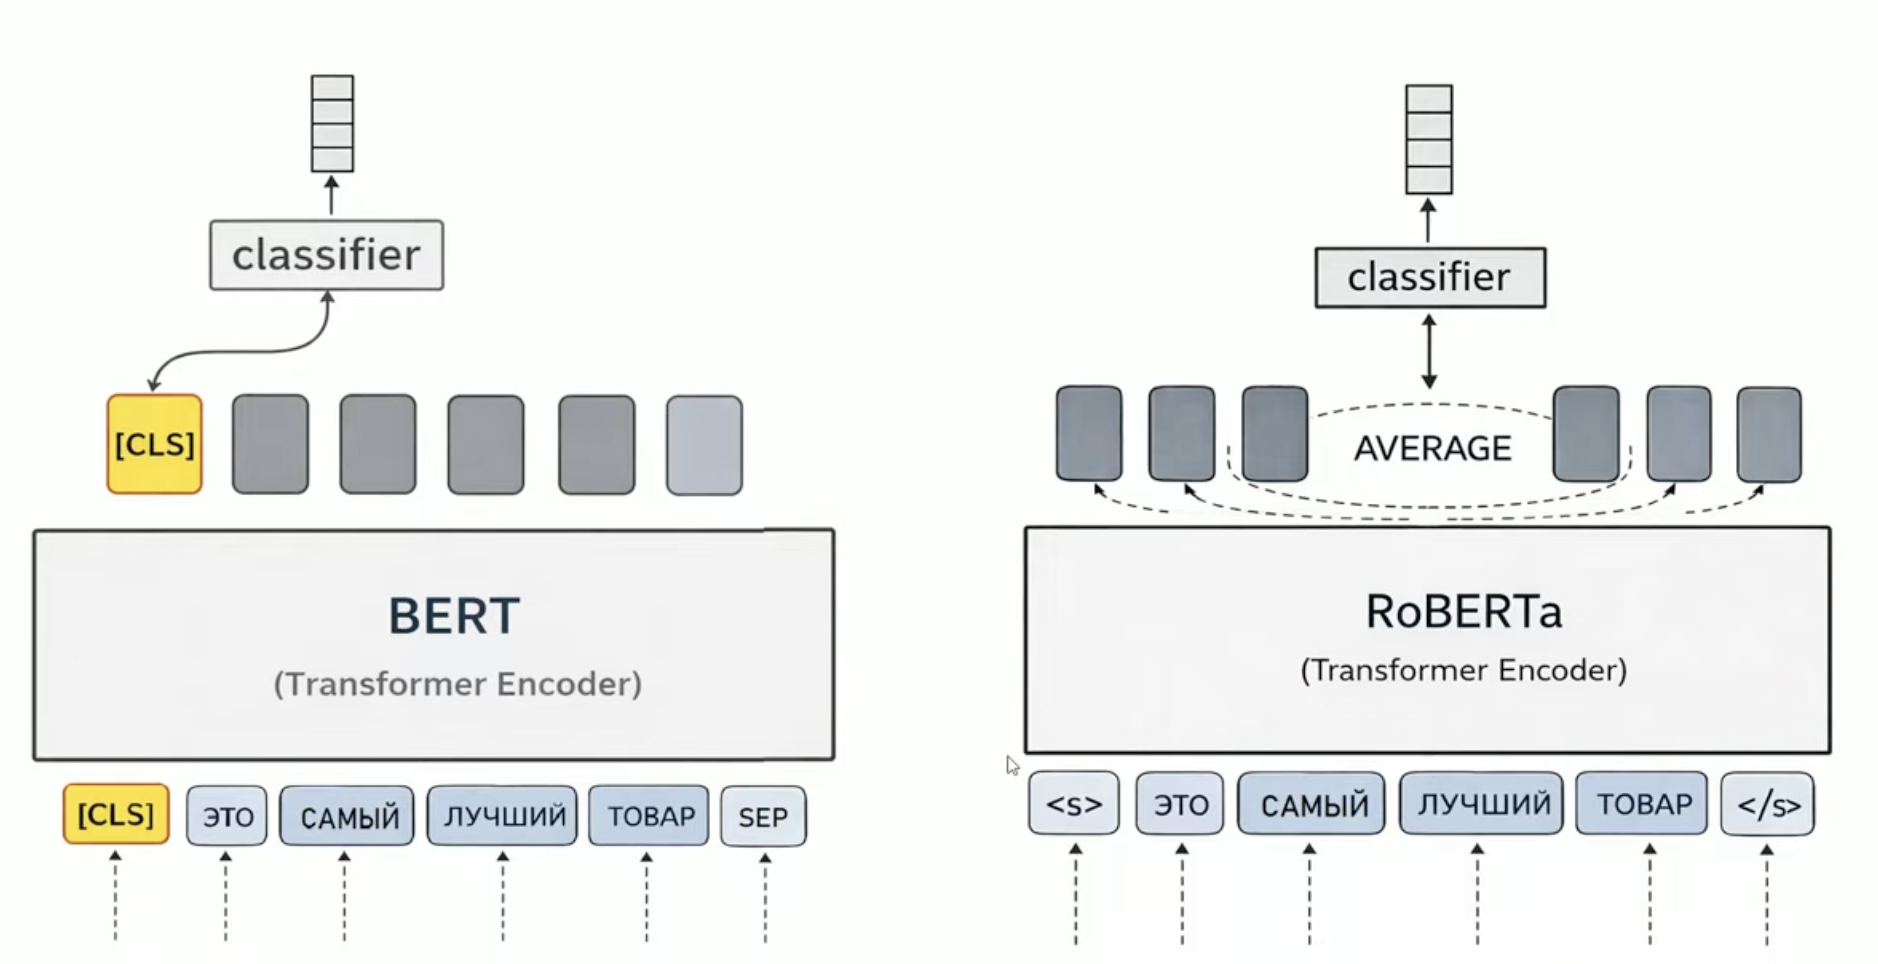

Два популярных вида - BERT-подобные и RoBERTa-подобные

У BERT-подобных есть специальный токен в начале CLS и модель так обучается, что хранит весь смысл в CLS и поэтому можно просто на выходе накинуть полносвязную сеть с классификацией(индекс 0 - токен в начале) и также есть токен SEPARATION

У roBERTa - есть токен начала и конца и при этом нет классификационного токена в начале, в этой архитектуре на выходе просто считаем среднее значение по всем векторам вышедших из энкодера и уже поверх среднего значения накидываем fully connected classifier

In [23]:
# Модель для классификации в случае если есть CLS токен
class BERT_Model(nn.Module):
    def __init__(self, model_name='DeepPavlov/rubert-base-cased'):
        super(BERT_Model, self).__init__()
        self.e5 = AutoModel.from_pretrained(model_name) ## инициализируем модель
        self.classifier = nn.Linear(self.e5.config.hidden_size, 1) # бинарная классификация
        
    def forward(self, input_ids, attention_mask):
        outputs = self.e5(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # Берем embedding первого токена [CLS - <s>]
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

У модели intfloat/multilingual-e5-small нет CLS токена. Первый токен 's' не обучен представлять всю последовательность, поэтому нужно усреднять эмбеддинги всех токенов (кроме padding)

In [24]:
class E5Classifier(nn.Module):
    def __init__(self, model_name='intfloat/multilingual-e5-small'):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        print("embed_dim = ", self.model.config.hidden_size)
        self.classifier = nn.Linear(self.model.config.hidden_size, 1) # бинарная классификация
        
    def mean_pooling(self, token_embeddings, attention_mask):
        """Усреднение векторов всех токенов кроме padding"""
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(
            token_embeddings.size()
        ).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask
        
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Average pooling
        pooled_output = self.mean_pooling(
            outputs.last_hidden_state, 
            attention_mask # по сути усреднение по всем векторам
        )
        
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

In [25]:
# Инициализируем модель
model = E5Classifier(model_name=MODEL_NAME)

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

embed_dim =  384


In [26]:
model

E5Classifier(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_af

In [27]:
# Функция для вычисления числа параметров
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

count_parameters(model)

(117654145, 117654145)

In [28]:
# Функция для вычисления метрик
def compute_metrics(predictions, labels, threshold=0.5):
    predictions_binary = (predictions > threshold).astype(int)
    accuracy = accuracy_score(labels, predictions_binary)
    f1 = f1_score(labels, predictions_binary)
    precision = precision_score(labels, predictions_binary)
    recall = recall_score(labels, predictions_binary)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [29]:

class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        """
        Focal Loss для бинарной классификации.
        
        Parameters
        ----------
        alpha : torch.Tensor
            Веса классов размером [2] для [класс_0, класс_1].
            Пример: torch.tensor([0.75, 0.25])
        gamma : float
            Параметр фокусировки. По умолчанию 2.0.
        reduction : str
            'mean', 'sum' или 'none'.
        """
        super().__init__()
        # Гарантируем, что alpha — это тензор с плавающей точкой
        self.alpha = alpha.float()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        inputs : torch.Tensor
            Логиты модели (без сигмоиды), форма [Batch, ...]
        targets : torch.Tensor
            Метки классов (0 или 1), форма [Batch, ...]
        """
        assert inputs.shape == targets.shape, f"Shape mismatch: {inputs.shape} vs {targets.shape}"
        
        # Приводим targets к long для gather и float для BCE
        targets_long = targets.long()
        targets_float = targets.float()

        # 1. Бинарная кросс-энтропия без редукции
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets_float, reduction="none"
        )

        # 2. Вероятность правильного класса (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Выбор веса alpha для каждого пикселя/элемента
        # Перемещаем alpha на то же устройство, что и данные
        alpha = self.alpha.to(inputs.device)
        
        # gather выбирает вес: если target=0 -> alpha[0], если target=1 -> alpha[1]
        alpha_t = alpha.gather(0, targets_long.view(-1)).view_as(targets)

        # 4. Фокусирующий коэффициент (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma

        # 5. Итоговый лосс
        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [30]:
def train_model(model, train_loader, val_loader, device, num_epochs=5):
    model.to(device)
    
    # Инициализация оптимизатора, функции потерь и планировщика
    # Расчет параметров
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.05 * total_steps)  # 5% warmup

    loss_func = FocalLoss(
        alpha=torch.tensor([0.5, 1.0]), 
        gamma=2.5
    )

    optimizer = AdamW(
        model.parameters(), 
        lr=3e-5, 
        weight_decay=0.01
    )

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps, # шедулер - 
        num_training_steps=total_steps
    )
    
    # Списки для сохранения истории лоссов (для построения графиков)
    train_losses = []
    val_losses = []
    
    best_val_f1 = 0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        
        # --- TRAIN ---
        model.train()
        total_train_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Training', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_func(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
        
        train_losses.append(total_train_loss / len(train_loader))
        
        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_labels = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Validation', leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = model(input_ids, attention_mask)
                
                # Считаем лосс валидации для графика
                loss = loss_func(outputs, labels)
                total_val_loss += loss.item()
                
                # Предсказания нужны только для расчета F1 (отбор лучшей модели)
                predictions = torch.sigmoid(outputs).cpu().numpy()
                val_predictions.extend(predictions)
                val_labels.extend(labels.cpu().numpy())
        
        val_losses.append(total_val_loss / len(val_loader))
        
        # Расчет метрик только для условия сохранения
        val_metrics = compute_metrics(np.array(val_predictions), np.array(val_labels))
        current_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']
        
        print(f'Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val accuracy: {val_acc:.3f} | Val F1: {current_f1:.3f}')
        
        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model weights updated due to improved validation F1 score")
    
    print(f'\nTraining Complete. Best validation F1: {best_val_f1:.4f}')
    
    # Возвращаем модель и историю лоссов
    return model, train_losses, val_losses

In [32]:
NUM_EPOCHS = 2

In [33]:
# Запуск обучения 
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

final_model, train_l, val_l = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch 1/2


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0142 | Val Loss: 0.0115 | Val accuracy: 0.969 | Val F1: 0.850
Model weights updated due to improved validation F1 score

Epoch 2/2


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0105 | Val Loss: 0.0112 | Val accuracy: 0.972 | Val F1: 0.860
Model weights updated due to improved validation F1 score

Training Complete. Best validation F1: 0.8597


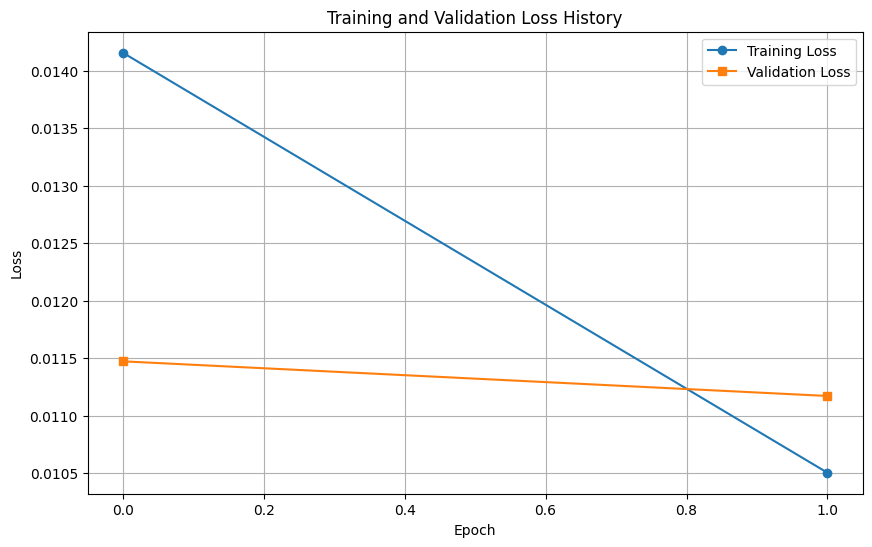

In [34]:
	
# Построение графика лосса от эпох
plt.figure(figsize=(10, 6))
plt.plot(train_l, label='Training Loss', marker='o')
plt.plot(val_l, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss History')
plt.legend()
plt.grid(True)
plt.show()

## Оценим качество на тесте

In [35]:

# Загружаем лучшую модель для финального тестирования
model.load_state_dict(torch.load('best_model.pth', map_location=device))

model.to(device).eval()

final_predictions = []
final_labels = []

# Сбор предсказаний на тестовом наборе
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask)
        predictions = torch.sigmoid(outputs).cpu().numpy()
        
        final_predictions.extend(predictions)
        final_labels.extend(labels.cpu().numpy())

# Конвертация в массивы
final_predictions = np.array(final_predictions).ravel()  # Важно: flatten для бинарной задачи
final_labels = np.array(final_labels).ravel()

  0%|          | 0/374 [00:00<?, ?it/s]

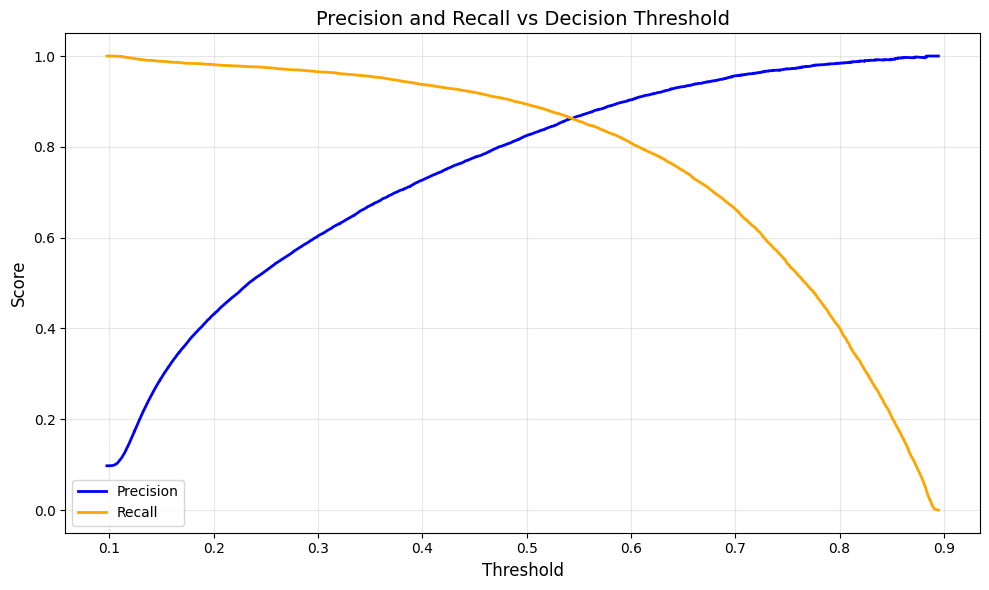

In [36]:
# --- Precision-Recall vs Threshold ---
# Расчет метрик для разных порогов
precisions, recalls, thresholds = precision_recall_curve(final_labels, final_predictions)

# Построение графика зависимости от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='orange')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Decision Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.9884    0.9795    0.9839     86312
         1.0     0.8248    0.8939    0.8580      9328

    accuracy                         0.9711     95640
   macro avg     0.9066    0.9367    0.9209     95640
weighted avg     0.9725    0.9711    0.9716     95640


CONFUSION MATRIX (threshold=0.5)


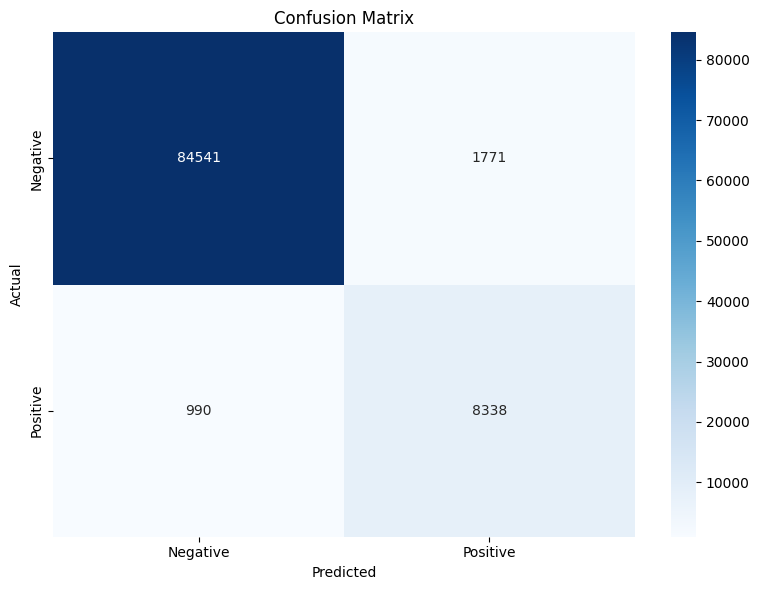

In [37]:
# Бинаризация предсказаний для основных метрик
threshold = 0.5
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Отсмотрим ошибки FP FN

In [38]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['label'] == 0)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(5, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 1771
СКОР от модели: 0.6466
Rating на сайте: 4.0000
ТЕКСТ: Была на дне рождении у подруги, роллы вкусные, но сервис не дотягивает. Обслуживание пока дождешься девушку быстрее сам сходишь возьмёшь себе приборы, уберешь салыетки, это просто очень не понравилось...
--------------------------------------------------------------------------------
СКОР от модели: 0.7971
Rating на сайте: 5.0000
ТЕКСТ: Я хочу чтобы все организации оказывающие услуги ТАК относились к клиенту! Как к самому дорогому и ценному гостю! Я пришла в первый раз на маникюр. Была записана на 10:00.Пришла по раньше 09:40.Несмотр...
--------------------------------------------------------------------------------
СКОР от модели: 0.5444
Rating на сайте: 5.0000
ТЕКСТ: Думала мою печать уже не восстановить, оказывается можно ещё и как
...
--------------------------------------------------------------------------------
СКОР от модели: 0.6773
Rating на сайте: 4.0000
ТЕКСТ: Цены достаточно высокие даже для М

## Оценка качества на своих примерах - инференс!

In [39]:
# Функция для предсказания на новых данных
def predict_texts(model, tokenizer, texts, device):
    model.eval()
    predictions = []
    
    for text in texts:
        encoding = tokenizer(
            str(text),
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )
        
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        
        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prob = torch.sigmoid(output).cpu().item()
            predictions.append(prob)
    
    return predictions

In [40]:
test_texts = [
    "Хорошее место. могу рекомендовать",
    "Хуже места не встечал!",
    "Это место топ 1 с конца по качеству",
    "Капец как плохо в этом заведении",
    "Капец как хорошо в этом заведении",
]
predict_texts(model=model, tokenizer=tokenizer, texts=test_texts, device=device)

[0.1427563726902008,
 0.7009044289588928,
 0.20795395970344543,
 0.8054080009460449,
 0.414394348859787]

## Можно интепретировать качество модели - LIME интерпретация

Модель прогонит текст и получит скор, а дальше будет по разному менять текст - переберет все возможные комбинации и поймет на каких словах больше всего происходит смещений от полного скора(когда все слова вместе) и так поймем какие именно слова роляют в модели

Probabilities: Neg=0.197, Pos=0.803
Predicted: Negative


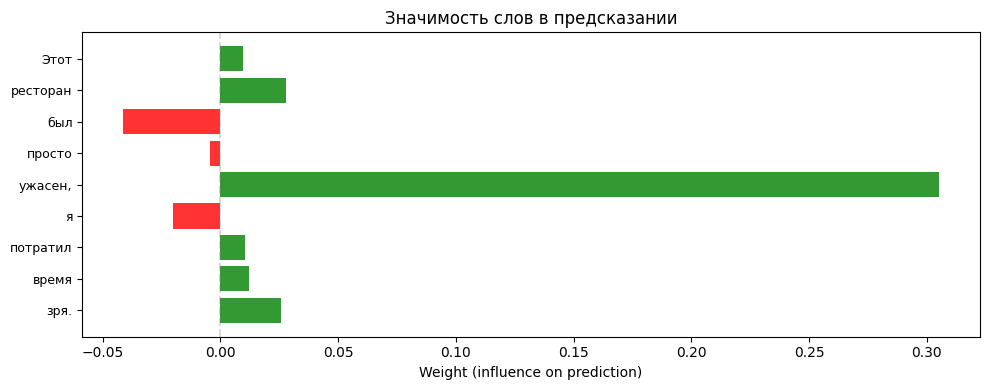

In [41]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer

def create_lime_predictor(model, tokenizer, device, max_length=512):
    model.eval()
    def predictor(texts):
        probs = []
        with torch.no_grad():
            for text in texts:
                enc = tokenizer(str(text), truncation=True, padding='max_length', 
                               max_length=max_length, return_tensors='pt')
                input_ids = enc['input_ids'].to(device)
                attention_mask = enc['attention_mask'].to(device)
                output = model(input_ids, attention_mask)
                prob_1 = torch.sigmoid(output).cpu().item()
                probs.append([1-prob_1, prob_1])
        return np.array(probs)
    return predictor

def plot_lime_explanation_original_order(explanation, text, top_n=10, figsize=(10, 4)):
    """Визуализация в порядке исходного текста"""
    # Получаем все слова с весами
    lime_dict = {word: weight for word, weight in explanation.as_list()}
    
    # Разбиваем исходный текст на слова (в оригинальном порядке)
    words_in_order = text.split()
    
    # Берём только те слова, для которых есть веса от LIME
    words = []
    weights = []
    for word in words_in_order:
        # Очищаем слово от знаков препинания для поиска
        clean_word = word.strip('.,!?;:')
        if clean_word in lime_dict and len(words) < top_n:
            words.append(word)
            weights.append(lime_dict[clean_word])
    
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    plt.figure(figsize=figsize)
    plt.barh(range(len(words)), weights, color=colors, alpha=0.8)
    plt.yticks(range(len(words)), words, fontsize=9)
    plt.xlabel('Weight (influence on prediction)')
    plt.title(f'Значимость слов в предсказании')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Этот ресторан был просто ужасен, я потратил время зря."
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

Probabilities: Neg=0.677, Pos=0.323
Predicted: Negative


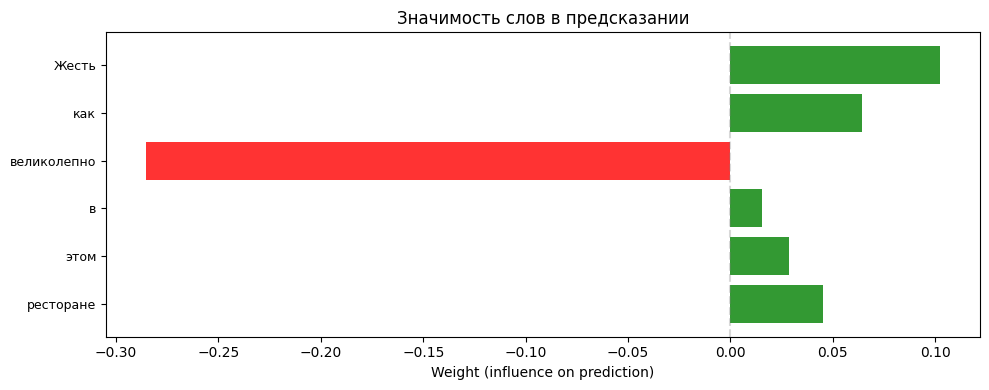

In [42]:
# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Жесть как великолепно в этом ресторане"
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

## Перевод модели в onnx

In [ ]:

# Создаем обертку для модели, которая добавляет reshape
class ModelWithReshape(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model
    
    def forward(self, input_ids, attention_mask):
        output = self.original_model(input_ids, attention_mask)
        # Добавляем размерность: [batch] -> [batch, 1]
        output = output.unsqueeze(-1)  # или output.reshape(-1, 1)
        return output

# Конвертация с оберткой
def convert_to_onnx(model, tokenizer, device, output_path="model.onnx", max_length=64):
    model.eval()
    
    # Оборачиваем модель
    wrapped_model = ModelWithReshape(model)
    wrapped_model.eval()
    
    dummy_text = "dummy text for onnx export"
    dummy_inputs = tokenizer(dummy_text, truncation=True, padding='max_length', 
                            max_length=max_length, return_tensors='pt')
    
    dummy_input_ids = dummy_inputs['input_ids'].to(device)
    dummy_attention_mask = dummy_inputs['attention_mask'].to(device)
    
    # Экспортируем обернутую модель
    torch.onnx.export(
        wrapped_model,  # используем обертку
        (dummy_input_ids, dummy_attention_mask),
        output_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['output'],
        dynamic_axes={
            'input_ids': {0: 'batch_size'},
            'attention_mask': {0: 'batch_size'},
            'output': {0: 'batch_size'} 
        },
        opset_version=14
    )
    
    print(f"Модель с выходом размерности [batch, 1] сохранена в {output_path}")
    
# Сохраняем модель
convert_to_onnx(model, tokenizer, device, "model.onnx", MAX_LENGTH)